حجم بيانات التدريب: (2344, 251)
حجم بيانات الاختبار: (586, 251)
------------------------------
متوسط الخطأ المطلق (MAE): 14764.60
جذر متوسط مربعات الخطأ (RMSE): 25009.38
دقة الموديل (R2 Score): 0.9106


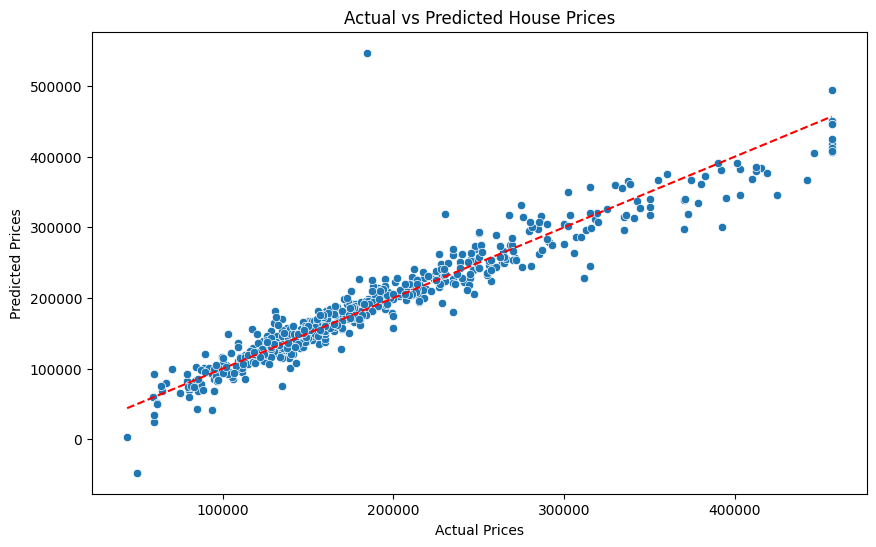

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. تحميل البيانات
df = pd.read_csv('Ames_Housing_Cleaned.csv')

# 2. تحويل النصوص إلى أرقام (حل مشكلة الخطأ ValueError)
# هذا السطر يحول الكلمات مثل 'RL' إلى أعمدة رقمية يفهمها الموديل
df = pd.get_dummies(df, drop_first=True)

# 3. تحديد المتغير التابع (السعر) والمميزات
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# 4. تقسيم البيانات (80% تدريب و 20% اختبار)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. بناء وتدريب الموديل
model = LinearRegression()
model.fit(X_train, y_train)

# 6. التنبؤ على بيانات الاختبار
predictions = model.predict(X_test)

# 7. طباعة نتائج الأداء (التقييم الرياضي)
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f"حجم بيانات التدريب: {X_train.shape}")
print(f"حجم بيانات الاختبار: {X_test.shape}")
print("-" * 30)
print(f"متوسط الخطأ المطلق (MAE): {mae:.2f}")
print(f"جذر متوسط مربعات الخطأ (RMSE): {rmse:.2f}")
print(f"دقة الموديل (R2 Score): {r2:.4f}")

# 8. رسم بياني للمقارنة بين السعر الحقيقي والمتوقع
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=predictions)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted House Prices')
plt.show()

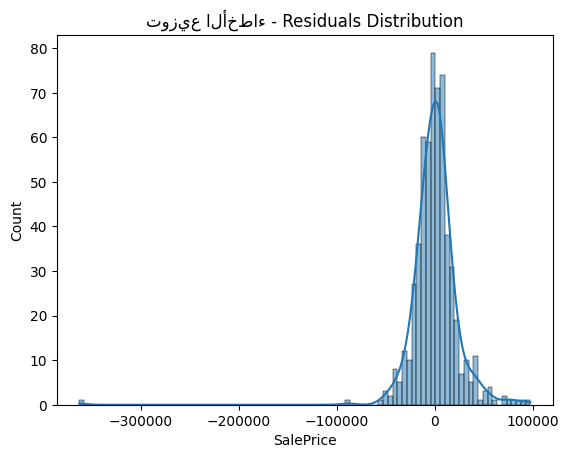

In [7]:
residuals = y_test - predictions
sns.histplot(residuals, kde=True)
plt.title('توزيع الأخطاء - Residuals Distribution')
plt.show()

In [8]:
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
top_features = coefficients.abs().sort_values('Coefficient', ascending=False).head(10)
print("أهم 10 عوامل مؤثرة في السعر:")
print(top_features)

أهم 10 عوامل مؤثرة في السعر:
                        Coefficient
Roof Matl_Membran     587324.216447
Roof Matl_Metal       566820.820315
Roof Matl_Roll        541999.942592
Roof Matl_Tar&Grv     537347.783373
Roof Matl_WdShngl     536725.714983
Roof Matl_WdShake     526301.994176
Roof Matl_CompShg     524887.779292
Neighborhood_GrnHill  105674.995664
Garage Qual_Po         99339.932824
Garage Qual_Fa         92993.379003
